In [121]:
# Librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

In [122]:
df = pd.read_csv('data/datos_preprocesados.csv')
df.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Personas_Cargo,Fiador,Impago,Prima,Estudios_encoded,Estado_Civil_Divorciado,Estado_Civil_Soltero,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
0,KG9CT9,34,56572,73978,763,86,1,13.91,60,0.55,...,0,0,0,800.00,2,0,1,0,0,1
1,V5O0K9,37,68698,150000,824,162,2,10.53,24,0.37,...,0,0,0,580.00,2,0,0,0,1,0
2,YE5GD0,40,50000,7490,671,167,2,9.24,60,0.10,...,1,0,0,130.00,1,0,0,0,0,0
3,Q6HQ3D,38,63033,11801,649,196,1,7.63,48,0.10,...,1,0,0,168.08,1,0,1,0,0,1
4,XO8CO4,19,22301,40000,788,17,4,8.40,36,0.50,...,1,1,0,293.94,0,0,1,0,1,0


In [123]:
# describe de varibales numéricas contínuas
df[['Ratio_Interes', 'Duracion', 'Ratio_Deuda_Ingresos', 'Prima', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio', 'Meses_Empleo', 'Num_Creditos']].describe()

,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Prima,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos
count,178606.000000,178606.000000,178606.000000,178606.000000,178606.000000,178606.000000,178606.000000,178606.000000,178606.000000
mean,10.676211,37.255523,0.321933,386.809055,41509.970740,45190.765937,692.053285,212.770601,2.001025
std,3.809254,14.166838,0.181164,267.648386,16036.504202,46648.083692,87.828224,150.688070,1.001298
min,2.010000,12.000000,0.100000,10.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000
25%,7.960000,24.000000,0.140000,138.880000,30484.250000,15126.000000,635.000000,70.000000,1.000000
50%,10.590000,36.000000,0.290000,340.095000,39090.500000,40000.000000,704.000000,208.000000,2.000000
75%,13.270000,48.000000,0.550000,621.670000,50096.750000,47626.500000,761.000000,336.000000,3.000000
max,24.440000,60.000000,0.550000,800.000000,120000.000000,400000.000000,845.000000,639.000000,4.000000


Las variables tienen escalas muy diferente, por lo que vamos a escalarlas

In [124]:
variables_categoricas = ['Num_Creditos', 'Posesion_Hipoteca', 'Personas_Cargo', 'Fiador', 'Estudios_encoded', 'Estado_Civil_Divorciado', 'Estado_Civil_Soltero', 'Tipo_Jornada_Laboral_Desempleado', 'Tipo_Jornada_Laboral_Jornada completa', 'Tipo_Jornada_Laboral_Tiempo parcial']

In [125]:
resumen = pd.DataFrame({
        "Frecuencia": df['Impago'].value_counts(),
        "Porcentaje": (
            df['Impago']
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })
resumen

,Frecuencia,Porcentaje
Impago,,
0,157832,88.37
1,20774,11.63


El 88.37% de los clientes han pagado y el 11.63% no. Un modelo de clasificación que sea útil debe de ser capaz de predecir correctamente un porcentaje de observaciones por encima del porcentaje de la clase mayoritaria. En este caso, el umbral de referencia que se tiene que superar es del 88.37%.

In [126]:
X = df.drop(columns=['Impago', 'ID'])
y = df['Impago']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y.values,
    train_size   = 0.8,
    random_state = 42,
    shuffle      = True,
    stratify = y
)

In [127]:
# Escalado de variables

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [128]:
modelo = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train, y_train)

c:\Users\izaro\RETO5\RETO5\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

### Ajuste del modelo con sklearn

In [129]:
modelo_log_sklearn = LogisticRegression( 
    class_weight='balanced',
    max_iter=2000,
    random_state=42)
modelo_log_sklearn.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [130]:
# Información del modelo
print("Intercept:", modelo_log_sklearn.intercept_)
print("Coeficiente:", list(zip(X.columns, modelo_log_sklearn.coef_.flatten(), )))
print("Accuracy de entrenamiento:", modelo_log_sklearn.score(X_train_scaled, y_train))

Intercept: [-0.18928157]
Coeficiente: [('Edad', np.float64(-0.3097609788919855)), ('Ingresos', np.float64(0.011567836503061738)), ('Monto_Inicial', np.float64(-0.059329338815185165)), ('Scoring_Crediticio', np.float64(-0.10695330305096953)), ('Meses_Empleo', np.float64(-0.26671955429196725)), ('Num_Creditos', np.float64(0.0010486667688361549)), ('Ratio_Interes', np.float64(0.4212122139534284)), ('Duracion', np.float64(0.0008381793889937966)), ('Ratio_Deuda_Ingresos', np.float64(0.016603484401535307)), ('Posesion_Hipoteca', np.float64(-0.01427543012461713)), ('Personas_Cargo', np.float64(-0.001690687546141955)), ('Fiador', np.float64(-0.0020310585455732507)), ('Prima', np.float64(-0.013323064793538087)), ('Estudios_encoded', np.float64(-0.01581196513578192)), ('Estado_Civil_Divorciado', np.float64(0.0071600485624801445)), ('Estado_Civil_Soltero', np.float64(0.00959064821254551)), ('Tipo_Jornada_Laboral_Desempleado', np.float64(0.003451766651863454)), ('Tipo_Jornada_Laboral_Jornada compl

Realizamos predicciones probabilísticas:

- Con .predict_proba() se obtiene, para cada observación, la probabilidad predicha de pertenecer a cada una de las dos clases.

- Con .predict() se obtiene, para cada observación, la clasificación predicha por el modelo. Esta clasificación se corresponde con la clase con mayor probabilidad.


In [131]:
# predict_proba()
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Probabilidad de impago del modelo balanceado
probabilidades_sklearn = modelo_log_sklearn.predict_proba(
    X_test_scaled
)[:, 1]

# Clasificación usando el umbral 0.5
clasificacion_sklearn = modelo_log_sklearn.predict(
    X_test_scaled
)

In [132]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

print("Cantidad de predicciones:")
print(pd.Series(clasificacion_sklearn).value_counts())

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, clasificacion_sklearn))

print("\nInforme de clasificación:")
print(classification_report(y_test, clasificacion_sklearn))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, probabilidades_sklearn)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, probabilidades_sklearn)
)

Cantidad de predicciones:
0    21236
1    14486
Name: count, dtype: int64

Matriz de confusión:
[[19784 11783]
 [ 1452  2703]]

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     31567
           1       0.19      0.65      0.29      4155

    accuracy                           0.63     35722
   macro avg       0.56      0.64      0.52     35722
weighted avg       0.84      0.63      0.70     35722

ROC-AUC: 0.6887743552508051
PR-AUC: 0.22374651766965797


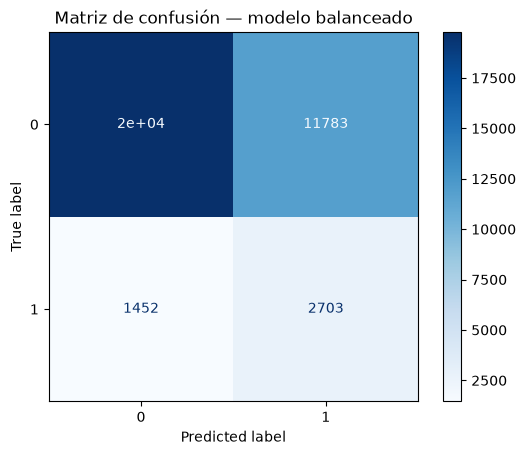

In [133]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    clasificacion_sklearn,
    cmap='Blues'
)

plt.title('Matriz de confusión — modelo balanceado')
plt.show()

In [134]:
# predict()

predicciones = modelo_log_sklearn.predict(X_test_scaled)
predicciones[:5]

array([1, 0, 1, 0, 0])

### Ajuste del modelo con statsmodel

In [135]:
# Creación del modelo utilizando matrices como sklearn

X_train_scaled = sm.add_constant(X_train_scaled, prepend=True)
modelo_log_statsm = sm.Logit(endog= y_train, exog = X_train_scaled)
modelo_log_statsm = modelo_log_statsm.fit()
print(modelo_log_statsm.summary())

Optimization terminated successfully.
         Current function value: 0.335707
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               142884
Model:                          Logit   Df Residuals:                   142864
Method:                           MLE   Df Model:                           19
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                 0.06621
Time:                        16:06:04   Log-Likelihood:                -47967.
converged:                       True   LL-Null:                       -51368.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.2156      

### Intervalos de confianza de los coeficientes

In [136]:
intervalos_ci = modelo_log_statsm.conf_int(alpha=0.05).rename(columns={0: "2.5%", 1: "97.5%"})

intervalos_ci[:19]

,2.5%,97.5%
const,-2.234523,-2.196727
Edad,-0.373692,-0.232059
Ingresos,-0.026375,0.043086
Monto_Inicial,-0.090976,-0.034188
Scoring_Crediticio,-0.120148,-0.084723
Meses_Empleo,-0.351688,-0.199026
Num_Creditos,-0.018345,0.014873
Ratio_Interes,0.392643,0.426610
Duracion,-0.021358,0.016244
Ratio_Deuda_Ingresos,-0.018994,0.032584


### Predicciones

- Stats model no tiene predict_proba(), la función predict nos proporciona las probabilidades asociadas a las predicciones

In [137]:
# Debemos añadir una columna de constante al conjunto de test 

X_test_scaled = sm.add_constant(X_test_scaled, has_constant='add')

predicciones = modelo_log_statsm.predict(exog = X_test_scaled)
predicciones[:19]

107239    0.118426
54936     0.034766
26047     0.144939
124006    0.083976
118177    0.108979
109416    0.119626
168030    0.065791
154279    0.032746
23675     0.146563
102881    0.213952
79461     0.047338
171129    0.023486
175053    0.049790
134059    0.079439
4833      0.110967
173304    0.095746
172666    0.199131
82738     0.076784
110672    0.085292
dtype: float64

In [138]:
# Hallamos la clasificación predicha estableciendo un umbral de probabilidad 0.5

clasificacion = np.where(predicciones<0.5, 0, 1)
clasificacion[:4]

array([0, 0, 0, 0])

### Métricas de rendimiento del modelo

- Accuracy

- precision

- sensibilidad (recall)

- f1-score

- Matriz de confusión

- Curva precisión/sensibilidad

- curva ROC-AUC

In [139]:
# Accuracy / Aciertos: 
""" 
Mide la proporción de predicciones correctas sobre el total de observaciones evaluadas
"""

from sklearn.metrics import accuracy_score

acierto = accuracy_score(y_test, clasificacion)
error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 88.37 %
Error: 11.63 %


In [140]:
# Precisión, Recall, f1-score
""" 
Precision: Cada vez que el modelo predijo una clase, acerto ese porcentaje
Recall: De todos los datos que eran de esa clase, detectó ese porcentaje
F1-score: El valor será alto si precisión y sensibilidad son similares, útil para comparar clasificadores.
"""



from sklearn.metrics import classification_report

print(classification_report(y_test, clasificacion))


              precision    recall  f1-score   support

           0       0.88      1.00      0.94     31567
           1       0.55      0.00      0.00      4155

    accuracy                           0.88     35722
   macro avg       0.71      0.50      0.47     35722
weighted avg       0.84      0.88      0.83     35722

